
# Major Project: Seasonal Agriculture Performance Analysis

**Platform:** Google Colab / Jupyter Notebook  
**Dataset:** `seasonal_agriculture_performance_dataset(1).csv`

This project analyzes agricultural performance across seasons, crops and regions, including environmental conditions, resource usage, yield, production and economic outcomes.



## 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. This project investigates seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations in the available data.



## 2. Objectives

- Explore and understand the dataset.
- Clean and prepare the data.
- Compare agricultural performance across seasons.
- Analyze crop and regional differences.
- Examine environmental conditions and resource usage.
- Study yield, production, revenue, cost and profit.
- Investigate relationships between agricultural factors and outcomes.
- Identify unusual patterns and outliers.
- Apply statistical and visualization techniques.
- Develop evidence-based conclusions and recommendations.


In [ ]:

# Cell 1 — Import libraries

!pip -q install scipy seaborn openpyxl

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from IPython.display import display, Markdown

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")


Libraries imported successfully.


In [ ]:

# Cell 2 — Upload dataset in Google Colab

df=pd.read_csv('seasonal_agriculture_performance_dataset.csv')
df.head()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [ ]:

# Cell 3 — Load dataset

file_name = "seasonal_agriculture_performance_dataset(1).csv"

if not os.path.exists(file_name):
    csv_files = [f for f in os.listdir(".") if f.lower().endswith(".csv")]
    if not csv_files:
        raise FileNotFoundError("No CSV file found. Upload the dataset first.")
    file_name = csv_files[0]

df = pd.read_csv(file_name)

print("File:", file_name)
print("Rows:", f"{df.shape[0]:,}")
print("Columns:", df.shape[1])

display(df.head())


File: cleaned_seasonal_agriculture_dataset.csv
Rows: 4,000
Columns: 33


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_Margin_pct,Cost_per_Tonne_INR,Revenue_per_Hectare_INR,Profit_per_Hectare_INR,Production_per_Hectare_Tonnes
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30,-38.47,"32,816.92","58,132.08","-22,362.26",2.45
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90,"-1,118.66","251,199.49","6,186.98","-69,211.33",0.30
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70,-65.49,"124,588.93","39,190.53","-25,667.49",0.52
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60,-47.68,"35,802.42","44,608.89","-21,267.56",1.84
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30,-74.56,"36,339.68","45,987.41","-34,287.89",2.21


In [ ]:

# Cell 4 — Dataset structure

print("Shape:", df.shape)

print("\nColumns:")
for i, col in enumerate(df.columns, 1):
    print(i, col)

print("\nData types:")
display(df.dtypes.to_frame("Data_Type"))


Shape: (4000, 33)

Columns:
1 Farm_ID
2 State
3 District
4 Crop
5 Season
6 Farm_Area_Hectares
7 Rainfall_mm
8 Avg_Temperature_C
9 Humidity_pct
10 Sunlight_Hours_Day
11 Soil_pH
12 Soil_Moisture_pct
13 Nitrogen_kg_ha
14 Phosphorus_kg_ha
15 Potassium_kg_ha
16 Irrigation_Method
17 Fertilizer_kg_ha
18 Pesticide_Litre_ha
19 Seed_Quality_Score
20 Yield_Tonnes_Ha
21 Production_Tonnes
22 Market_Price_INR_Tonne
23 Total_Cost_INR
24 Revenue_INR
25 Profit_INR
26 Water_Used_m3
27 Water_Efficiency_t_per_1000m3
28 Disease_Pest_Risk_pct
29 Profit_Margin_pct
30 Cost_per_Tonne_INR
31 Revenue_per_Hectare_INR
32 Profit_per_Hectare_INR
33 Production_per_Hectare_Tonnes

Data types:


,Data_Type
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [ ]:

# Cell 5 — Statistical overview

display(df.describe(include="all").T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF10001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,"4,000.00",NaN,NaN,NaN,7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"4,000.00",NaN,NaN,NaN,600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20"
Avg_Temperature_C,"4,000.00",NaN,NaN,NaN,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",NaN,NaN,NaN,63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",NaN,NaN,NaN,7.32,1.12,3.50,6.60,7.30,8.10,11.00


In [ ]:

# Cell 6 — Missing values

missing = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": df.isna().mean() * 100
}).sort_values("Missing_Count", ascending=False)

display(missing[missing["Missing_Count"] > 0])


,Missing_Count,Missing_Percentage


In [ ]:

# Cell 7 — Duplicate records

print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [ ]:

# Cell 8 — Categorical variables

categorical_cols = ["State", "District", "Crop", "Season", "Irrigation_Method"]

for col in categorical_cols:
    print(f"\n{col} — {df[col].nunique()} unique values")
    print(df[col].value_counts(dropna=False).head(15))



State — 8 unique values
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

District — 10 unique values
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

Crop — 8 unique values
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Season — 3 unique values
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Irrigation_Method — 4 unique values
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


## 3. Data Cleaning and Preparation

In [ ]:

# Cell 9 — Clean the dataset

data = df.copy()

# Remove exact duplicates
data = data.drop_duplicates().reset_index(drop=True)

# Clean text fields
for col in categorical_cols:
    data[col] = data[col].astype("string").str.strip()

# Convert numeric fields
for col in data.select_dtypes(include=np.number).columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Numeric missing values → median
for col in data.select_dtypes(include=np.number).columns:
    if data[col].isna().any():
        data[col] = data[col].fillna(data[col].median())

# Categorical missing values → mode
for col in data.select_dtypes(include=["object", "string", "category"]).columns:
    if data[col].isna().any():
        mode = data[col].mode(dropna=True)
        if len(mode):
            data[col] = data[col].fillna(mode.iloc[0])

print("Rows after cleaning:", len(data))
print("Missing values remaining:", data.isna().sum().sum())
print("Duplicates remaining:", data.duplicated().sum())


Rows after cleaning: 4000
Missing values remaining: 0
Duplicates remaining: 0


In [ ]:

# Cell 10 — Validate important ranges

range_checks = {
    "Farm_Area_Hectares": (0, np.inf),
    "Rainfall_mm": (0, np.inf),
    "Humidity_pct": (0, 100),
    "Sunlight_Hours_Day": (0, 24),
    "Soil_Moisture_pct": (0, 100),
    "Seed_Quality_Score": (0, 1),
    "Yield_Tonnes_Ha": (0, np.inf),
    "Production_Tonnes": (0, np.inf),
    "Total_Cost_INR": (0, np.inf),
    "Revenue_INR": (0, np.inf),
    "Water_Used_m3": (0, np.inf),
    "Water_Efficiency_t_per_1000m3": (0, np.inf),
    "Disease_Pest_Risk_pct": (0, 100)
}

for col, (low, high) in range_checks.items():
    if col in data.columns:
        bad = ((data[col] < low) | (data[col] > high)).sum()
        print(f"{col}: {bad} outside expected range")


Farm_Area_Hectares: 0 outside expected range
Rainfall_mm: 0 outside expected range
Humidity_pct: 0 outside expected range
Sunlight_Hours_Day: 0 outside expected range
Soil_Moisture_pct: 0 outside expected range
Seed_Quality_Score: 0 outside expected range
Yield_Tonnes_Ha: 0 outside expected range
Production_Tonnes: 0 outside expected range
Total_Cost_INR: 0 outside expected range
Revenue_INR: 0 outside expected range
Water_Used_m3: 0 outside expected range
Water_Efficiency_t_per_1000m3: 0 outside expected range
Disease_Pest_Risk_pct: 0 outside expected range


## 4. Feature Engineering

In [ ]:

# Cell 11 — Create additional analytical variables

data["Profit_Margin_pct"] = np.where(
    data["Revenue_INR"] > 0,
    data["Profit_INR"] / data["Revenue_INR"] * 100,
    np.nan
)

data["Cost_per_Tonne_INR"] = np.where(
    data["Production_Tonnes"] > 0,
    data["Total_Cost_INR"] / data["Production_Tonnes"],
    np.nan
)

data["Revenue_per_Hectare_INR"] = np.where(
    data["Farm_Area_Hectares"] > 0,
    data["Revenue_INR"] / data["Farm_Area_Hectares"],
    np.nan
)

data["Profit_per_Hectare_INR"] = np.where(
    data["Farm_Area_Hectares"] > 0,
    data["Profit_INR"] / data["Farm_Area_Hectares"],
    np.nan
)

data["Production_per_Hectare_Tonnes"] = np.where(
    data["Farm_Area_Hectares"] > 0,
    data["Production_Tonnes"] / data["Farm_Area_Hectares"],
    np.nan
)

display(data.head())


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Profit_Margin_pct,Cost_per_Tonne_INR,Revenue_per_Hectare_INR,Profit_per_Hectare_INR,Production_per_Hectare_Tonnes
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30,-38.47,"32,816.92","58,132.08","-22,362.26",2.45
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90,"-1,118.66","251,199.49","6,186.98","-69,211.33",0.30
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70,-65.49,"124,588.93","39,190.53","-25,667.49",0.52
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60,-47.68,"35,802.42","44,608.89","-21,267.56",1.84
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30,-74.56,"36,339.68","45,987.41","-34,287.89",2.21


## 5. Exploratory Data Analysis

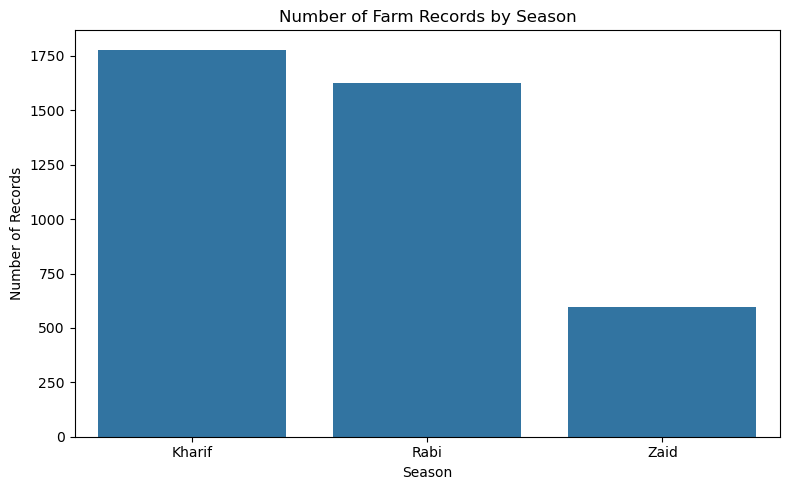

,Record_Count
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [ ]:

# Cell 12 — Season distribution

season_counts = data["Season"].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=season_counts.index, y=season_counts.values)
plt.title("Number of Farm Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

display(season_counts.to_frame("Record_Count"))


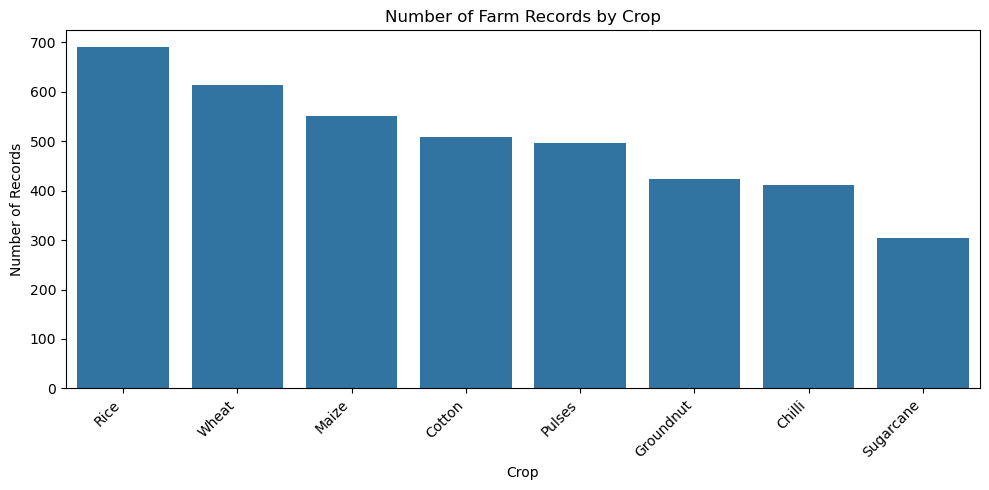

In [ ]:

# Cell 13 — Crop distribution

crop_counts = data["Crop"].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=crop_counts.index, y=crop_counts.values)
plt.title("Number of Farm Records by Crop")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


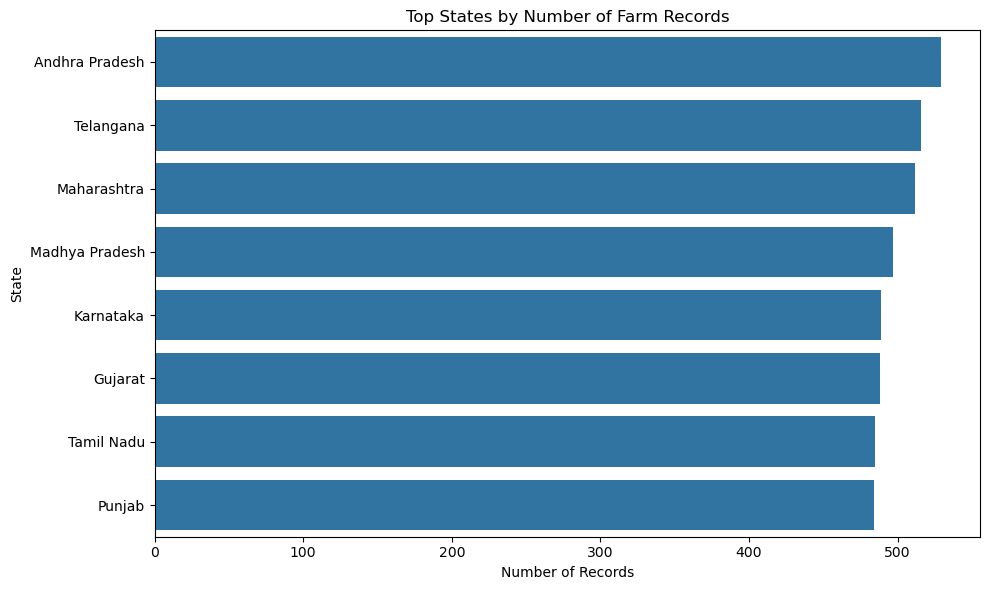

In [ ]:

# Cell 14 — State distribution

state_counts = data["State"].value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(y=state_counts.index, x=state_counts.values)
plt.title("Top States by Number of Farm Records")
plt.xlabel("Number of Records")
plt.ylabel("State")
plt.tight_layout()
plt.show()


## 6. Key Question 1 — How does agricultural performance vary across seasons?

In [ ]:

# Cell 15 — Seasonal performance summary

season_summary = data.groupby("Season").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "mean"),
    Avg_Production_Tonnes=("Production_Tonnes", "mean"),
    Avg_Revenue_INR=("Revenue_INR", "mean"),
    Avg_Cost_INR=("Total_Cost_INR", "mean"),
    Avg_Profit_INR=("Profit_INR", "mean"),
    Avg_Water_Used_m3=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Disease_Pest_Risk_pct=("Disease_Pest_Risk_pct", "mean")
).sort_values("Avg_Profit_INR", ascending=False)

display(season_summary.round(2))


,Farms,Avg_Yield_Tonnes_Ha,Avg_Production_Tonnes,Avg_Revenue_INR,Avg_Cost_INR,Avg_Profit_INR,Avg_Water_Used_m3,Avg_Water_Efficiency,Avg_Disease_Pest_Risk_pct
Season,,,,,,,,,
Kharif,1779,5.63,46.31,"710,719.06","531,804.41","178,914.65","6,102.20",5.89,54.47
Rabi,1627,5.04,41.49,"601,526.05","513,836.58","87,689.47","5,846.99",5.19,40.48
Zaid,594,4.64,38.89,"519,171.90","543,976.73","-24,804.82","6,419.89",4.41,38.22


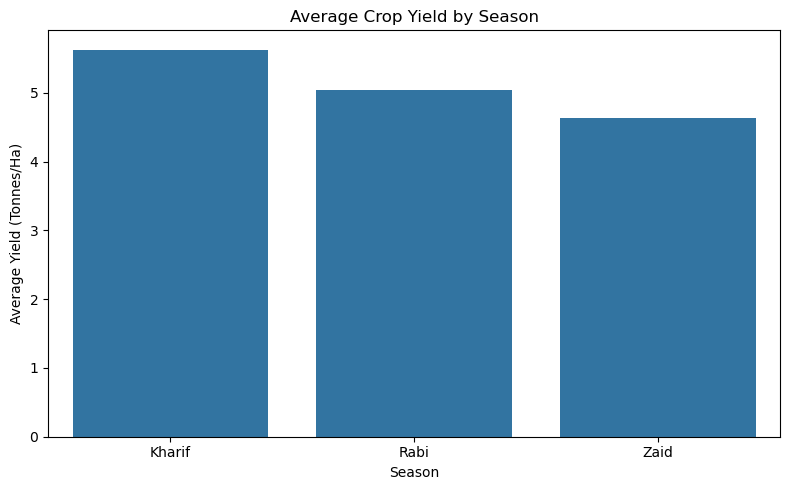

Highest average yield season: Kharif


In [ ]:

# Cell 16 — Average yield by season

plt.figure(figsize=(8, 5))
sns.barplot(data=data, x="Season", y="Yield_Tonnes_Ha", estimator=np.mean, errorbar=None)
plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

best_yield_season = season_summary["Avg_Yield_Tonnes_Ha"].idxmax()
print("Highest average yield season:", best_yield_season)


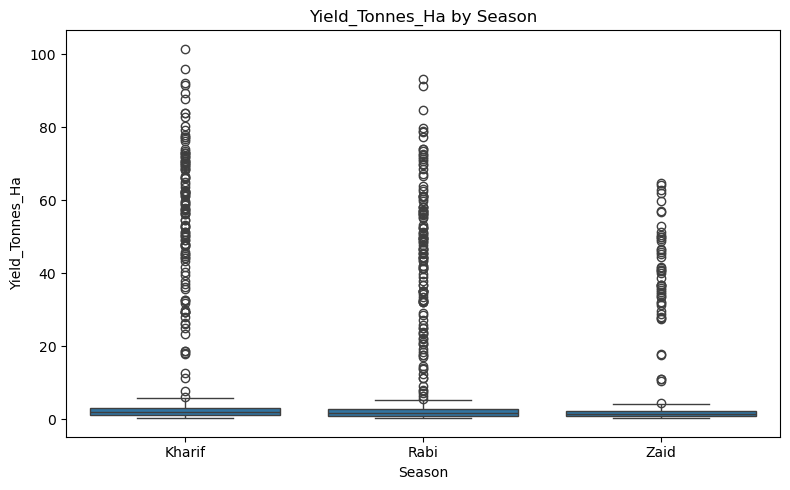

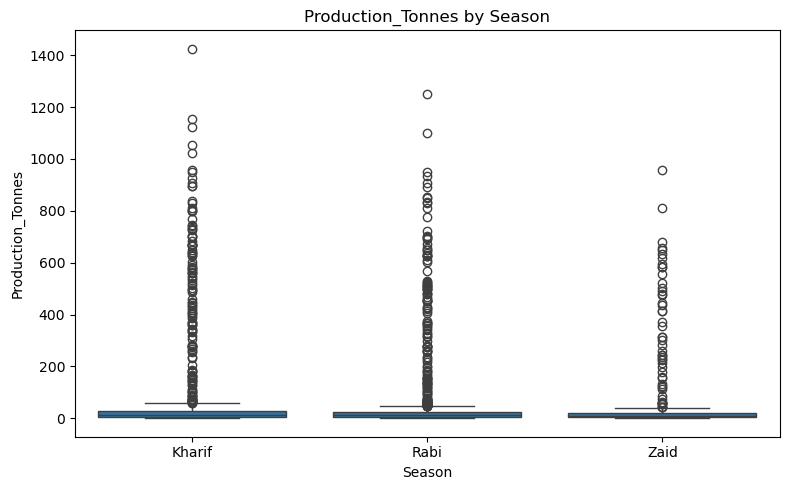

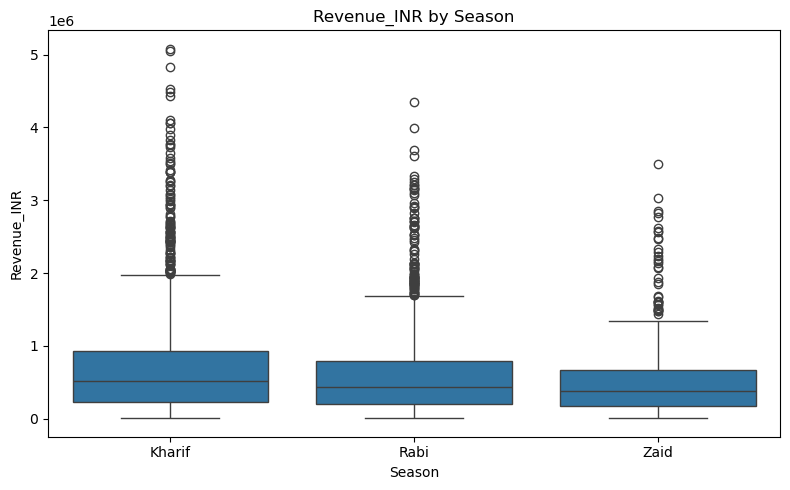

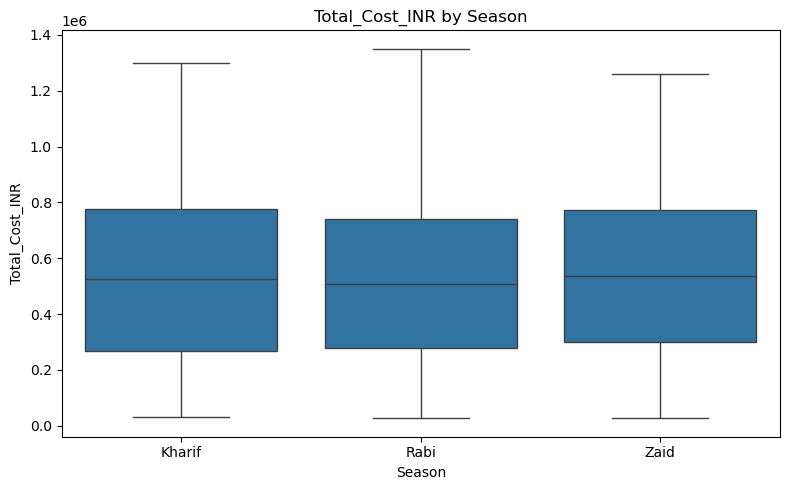

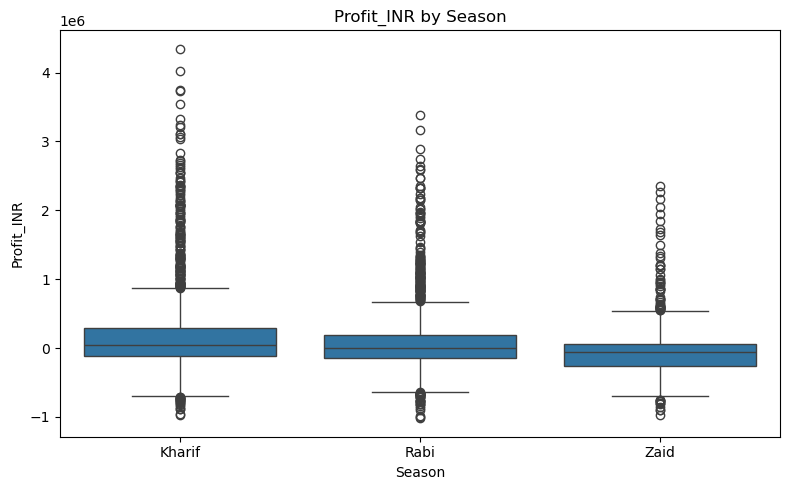

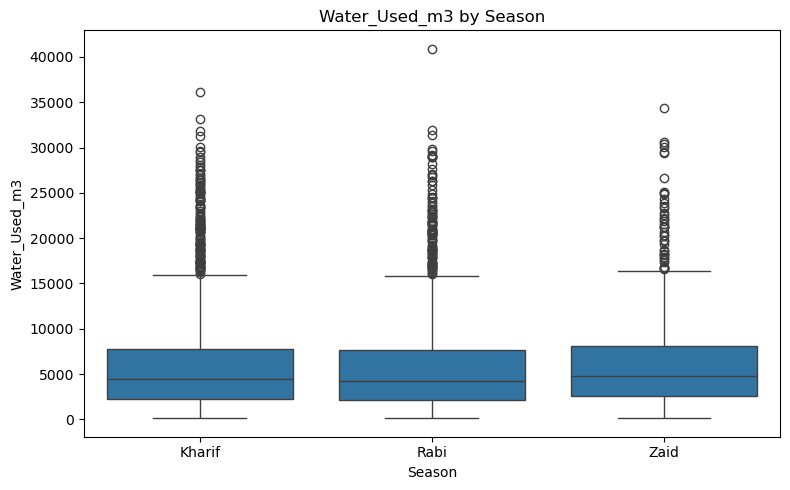

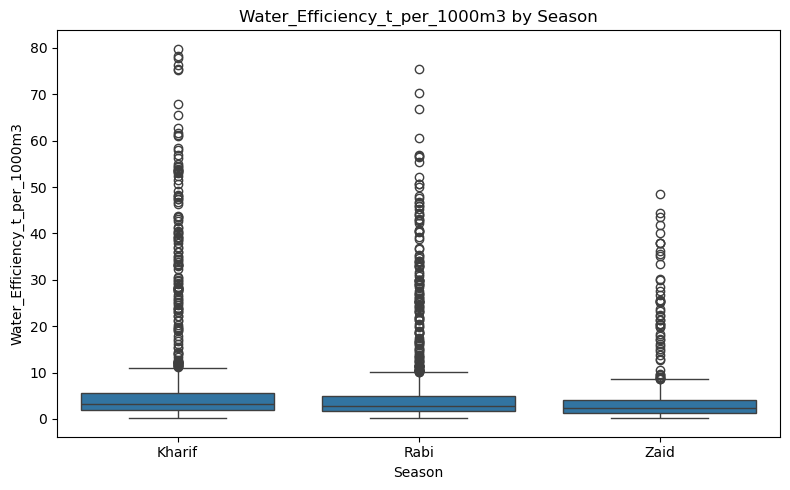

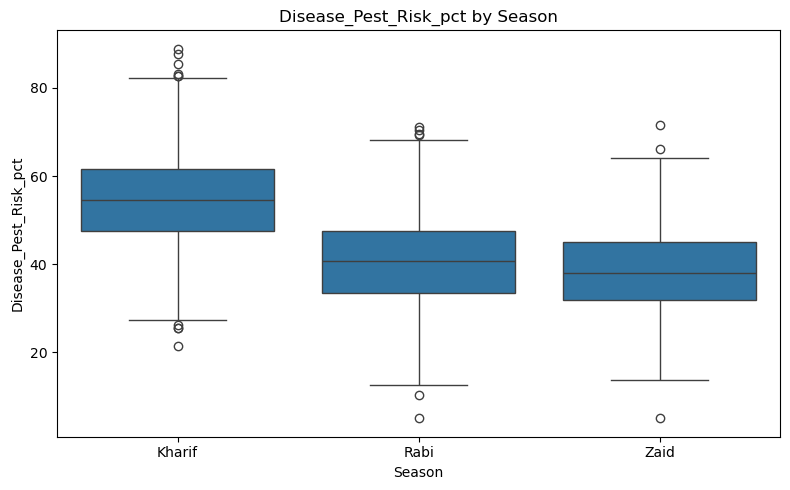

In [ ]:

# Cell 17 — Seasonal KPI boxplots

metrics = [
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Revenue_INR",
    "Total_Cost_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

for metric in metrics:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=data, x="Season", y=metric)
    plt.title(f"{metric} by Season")
    plt.xlabel("Season")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()


## 7. Key Question 2 — Which crops perform best in each season?

In [ ]:

# Cell 18 — Crop-season performance

crop_season = data.groupby(["Season", "Crop"]).agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Revenue=("Revenue_INR", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).reset_index()

display(crop_season.sort_values(["Season", "Avg_Yield"], ascending=[True, False]).round(2))


,Season,Crop,Farms,Avg_Yield,Avg_Profit,Avg_Revenue,Avg_Water_Efficiency
6,Kharif,Sugarcane,125,53.46,"1,000,790.81","1,561,828.16",36.00
3,Kharif,Maize,234,2.97,"-39,332.67","486,047.01",6.05
5,Kharif,Rice,314,2.70,"-64,903.40","491,546.11",2.17
7,Kharif,Wheat,292,2.25,"-105,871.87","431,595.94",4.76
0,Kharif,Chilli,185,1.73,"954,380.42","1,494,091.73",3.26
2,Kharif,Groundnut,193,1.48,"108,265.44","594,414.86",3.58
1,Kharif,Cotton,215,1.37,"216,999.55","713,739.94",2.13
4,Kharif,Pulses,221,1.04,"43,338.90","590,276.29",3.35
14,Rabi,Sugarcane,129,43.29,"731,612.86","1,269,754.74",27.92
11,Rabi,Maize,233,2.60,"-89,133.40","454,728.04",5.46


In [ ]:

# Cell 19 — Best crop by yield in each season

best_crop_by_season = (
    crop_season.sort_values(["Season", "Avg_Yield"], ascending=[True, False])
    .groupby("Season")
    .head(1)
)

display(best_crop_by_season.round(2))


,Season,Crop,Farms,Avg_Yield,Avg_Profit,Avg_Revenue,Avg_Water_Efficiency
6,Kharif,Sugarcane,125,53.46,"1,000,790.81","1,561,828.16",36.00
14,Rabi,Sugarcane,129,43.29,"731,612.86","1,269,754.74",27.92
22,Zaid,Sugarcane,51,38.42,"583,635.80","1,165,236.35",23.39


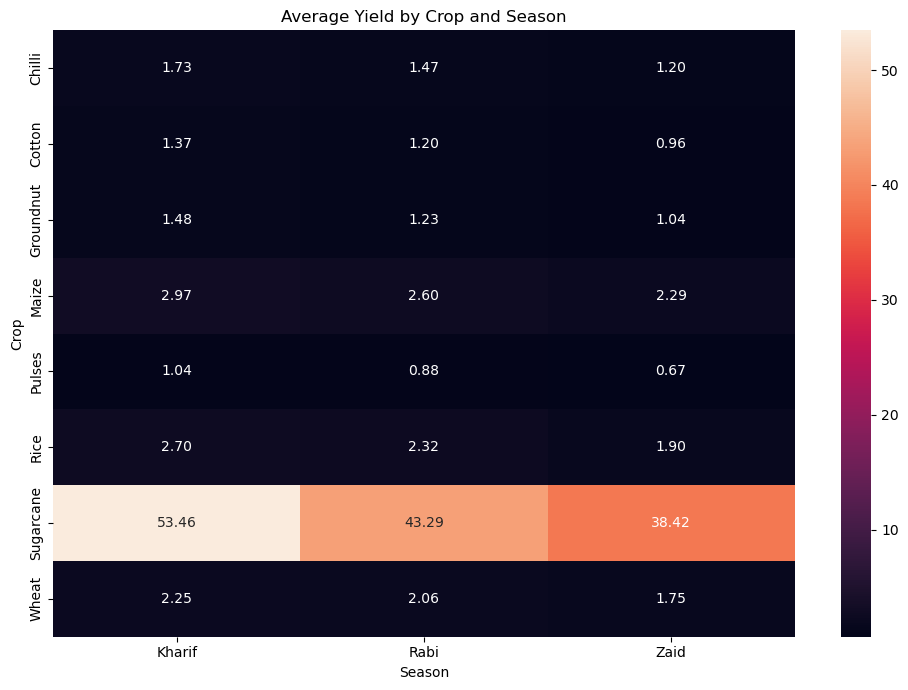

In [ ]:

# Cell 20 — Crop × Season yield heatmap

yield_pivot = data.pivot_table(
    index="Crop",
    columns="Season",
    values="Yield_Tonnes_Ha",
    aggfunc="mean"
)

plt.figure(figsize=(10, 7))
sns.heatmap(yield_pivot, annot=True, fmt=".2f")
plt.title("Average Yield by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()


## 8. Key Question 3 — Which regions have stronger agricultural performance?

In [ ]:

# Cell 21 — State-wise performance

state_summary = data.groupby("State").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Production=("Production_Tonnes", "mean"),
    Avg_Revenue=("Revenue_INR", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).sort_values("Avg_Profit", ascending=False)

display(state_summary.round(2))


,Farms,Avg_Yield,Avg_Production,Avg_Revenue,Avg_Profit,Avg_Water_Efficiency
State,,,,,,
Punjab,484,6.12,52.23,"686,225.70","136,025.64",5.62
Maharashtra,512,5.02,43.98,"650,032.67","135,428.86",5.28
Karnataka,489,5.69,47.73,"653,426.18","119,422.34",5.56
Tamil Nadu,485,4.88,40.84,"629,093.42","117,744.75",5.31
Gujarat,488,5.66,48.33,"654,692.86","117,568.24",5.58
Telangana,516,5.04,39.25,"628,784.53","108,829.62",5.46
Madhya Pradesh,497,4.99,37.56,"597,558.36","86,840.76",5.27
Andhra Pradesh,529,4.63,36.91,"606,663.66","73,453.53",5.03


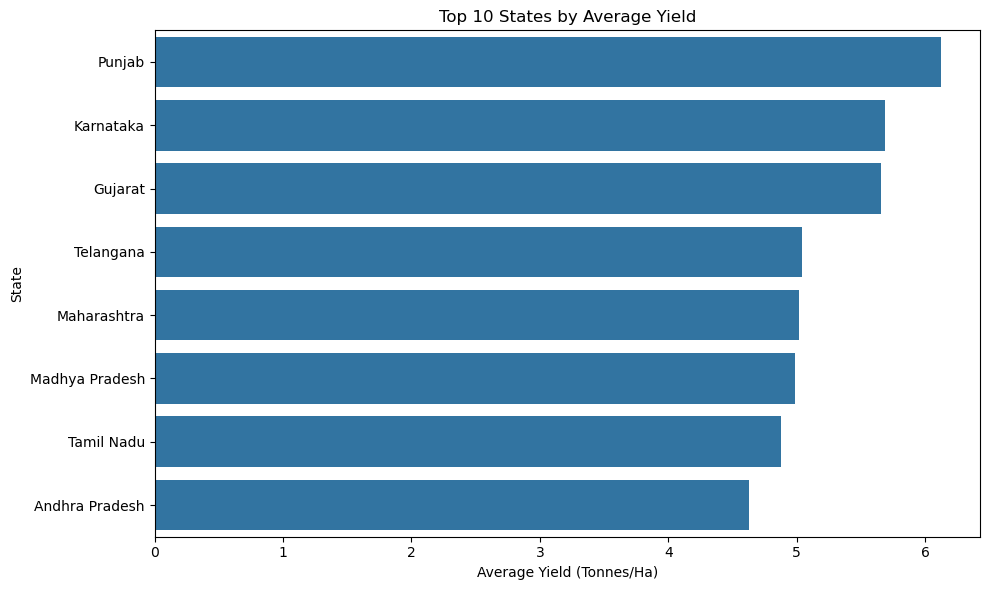

In [ ]:

# Cell 22 — Top states by average yield

top_states = state_summary.sort_values("Avg_Yield", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(y=top_states.index, x=top_states["Avg_Yield"])
plt.title("Top 10 States by Average Yield")
plt.xlabel("Average Yield (Tonnes/Ha)")
plt.ylabel("State")
plt.tight_layout()
plt.show()


## 9. Key Question 4 — What is the relationship between environmental conditions and yield?

In [ ]:

# Cell 23 — Environmental correlations

environmental_cols = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct"
]

environment_corr = (
    data[environmental_cols + ["Yield_Tonnes_Ha"]]
    .corr()["Yield_Tonnes_Ha"]
    .drop("Yield_Tonnes_Ha")
    .sort_values(key=abs, ascending=False)
)

display(environment_corr.to_frame("Correlation_with_Yield"))


,Correlation_with_Yield
Rainfall_mm,0.03
Soil_pH,-0.02
Sunlight_Hours_Day,-0.02
Humidity_pct,0.01
Soil_Moisture_pct,0.01
Avg_Temperature_C,0.01


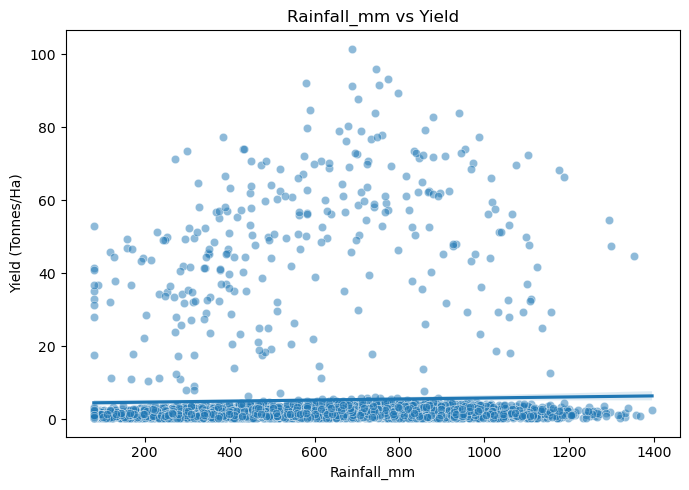

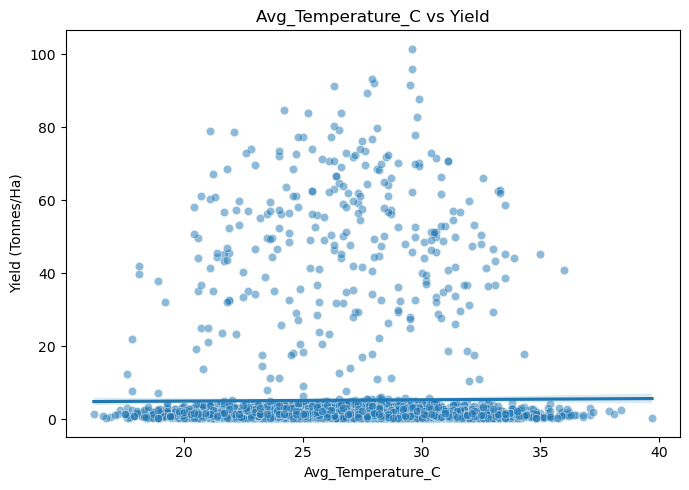

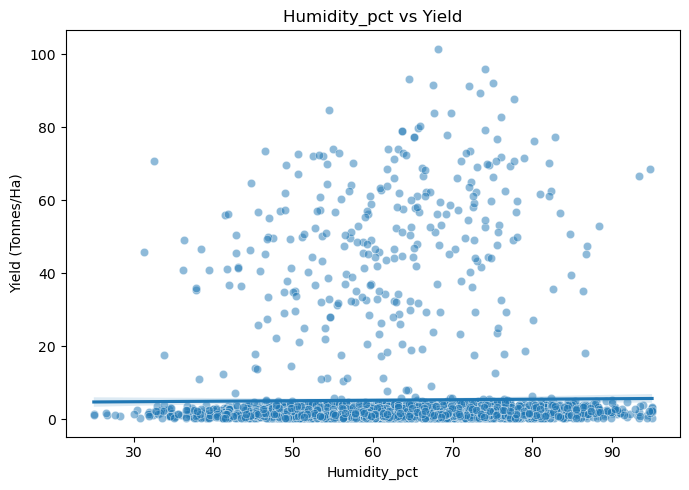

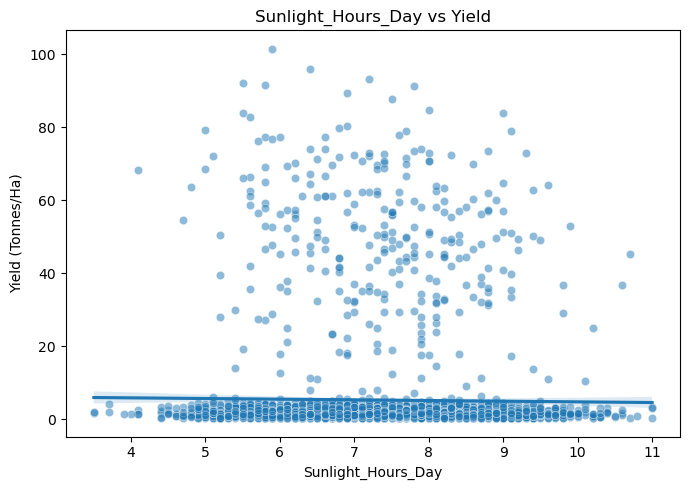

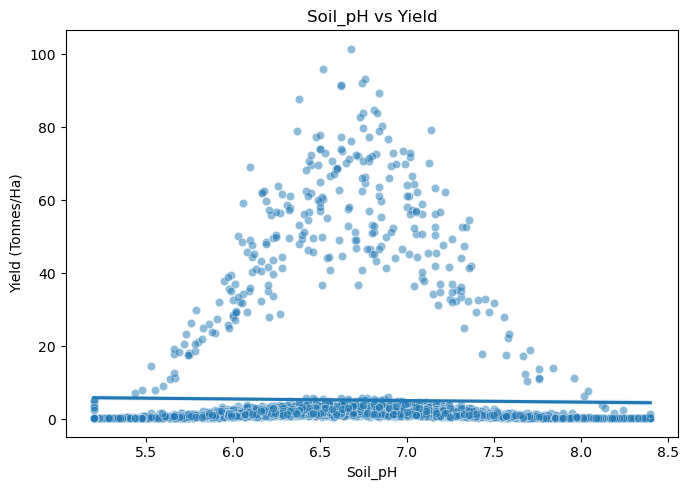

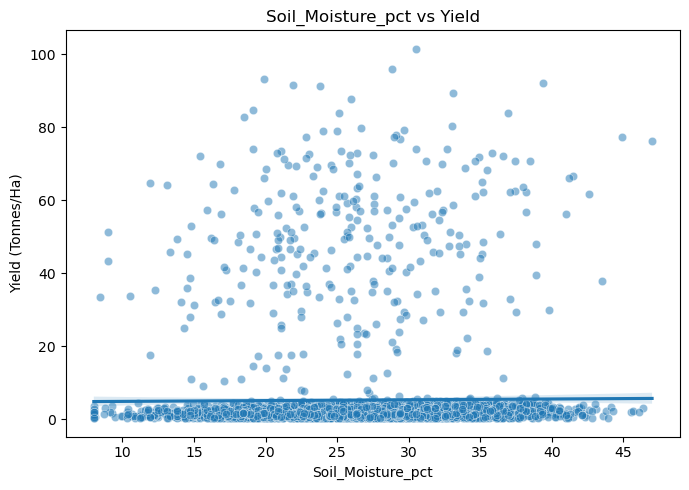

In [ ]:

# Cell 24 — Environmental factors vs yield

for col in environmental_cols:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=data, x=col, y="Yield_Tonnes_Ha", alpha=0.5)
    sns.regplot(data=data, x=col, y="Yield_Tonnes_Ha", scatter=False)
    plt.title(f"{col} vs Yield")
    plt.xlabel(col)
    plt.ylabel("Yield (Tonnes/Ha)")
    plt.tight_layout()
    plt.show()


## 10. Key Question 5 — How do resources and irrigation affect performance?

In [ ]:

# Cell 25 — Resource usage by season

resource_cols = [
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Water_Used_m3"
]

resource_season = data.groupby("Season")[resource_cols].mean()
display(resource_season.round(2))


,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3
Season,,,,,,
Kharif,120.02,58.10,105.30,187.08,5.08,"6,102.20"
Rabi,120.40,57.31,103.93,185.41,5.02,"5,846.99"
Zaid,120.53,58.13,105.42,184.64,5.17,"6,419.89"


,Farms,Avg_Yield,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency
Irrigation_Method,,,,,
Drip,915,6.58,"219,626.00","5,918.75",6.27
Sprinkler,734,5.16,"91,121.08","6,208.26",4.67
Flood,1310,4.86,"73,354.02","8,026.47",3.44
Rainfed,1041,4.60,"79,050.37","3,549.55",7.56


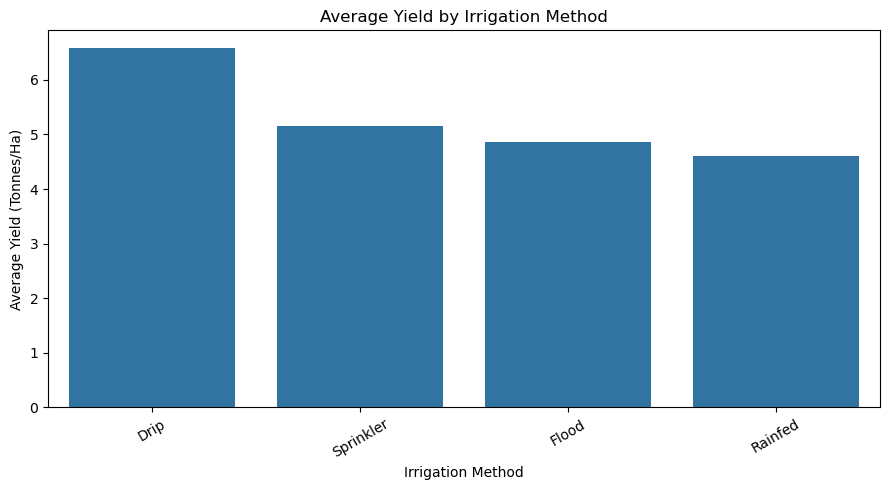

In [ ]:

# Cell 26 — Irrigation method comparison

irrigation_summary = data.groupby("Irrigation_Method").agg(
    Farms=("Farm_ID", "count"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Water_Used=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).sort_values("Avg_Yield", ascending=False)

display(irrigation_summary.round(2))

plt.figure(figsize=(9, 5))
sns.barplot(
    data=irrigation_summary.reset_index(),
    x="Irrigation_Method",
    y="Avg_Yield"
)
plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


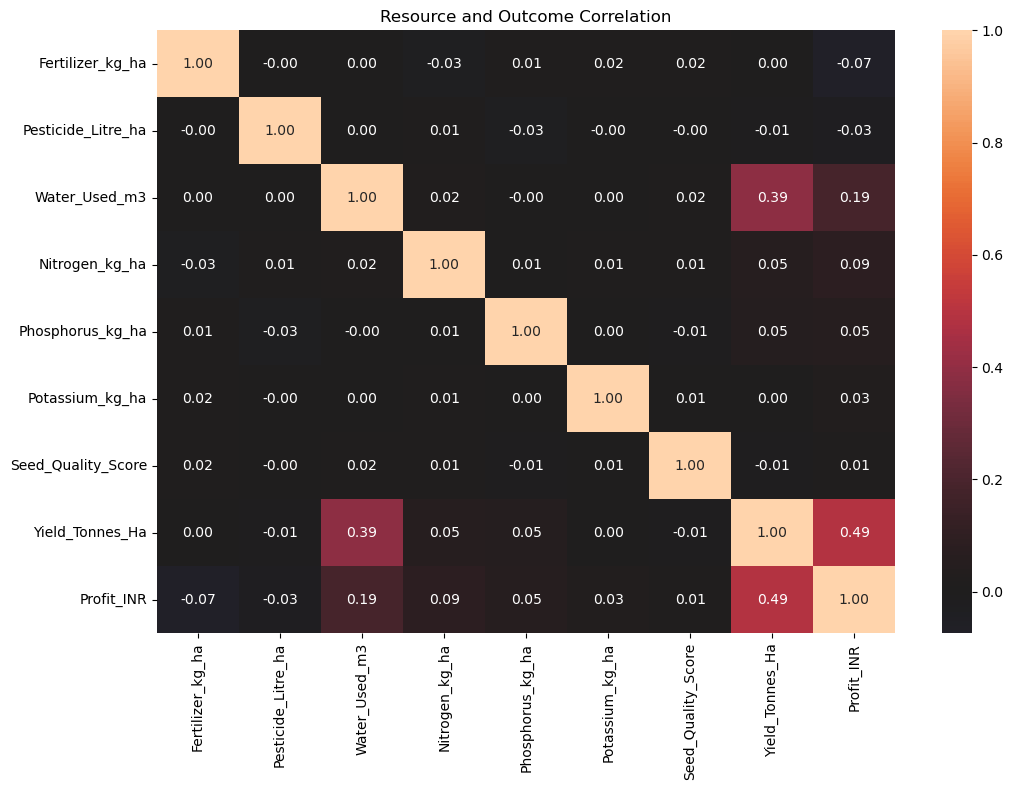

In [ ]:

# Cell 27 — Resources vs yield/profit correlation

resource_outcomes = [
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Water_Used_m3",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha",
    "Profit_INR"
]

resource_corr = data[resource_outcomes].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(resource_corr, annot=True, fmt=".2f", center=0)
plt.title("Resource and Outcome Correlation")
plt.tight_layout()
plt.show()


## 11. Key Question 6 — How does seed quality relate to yield?

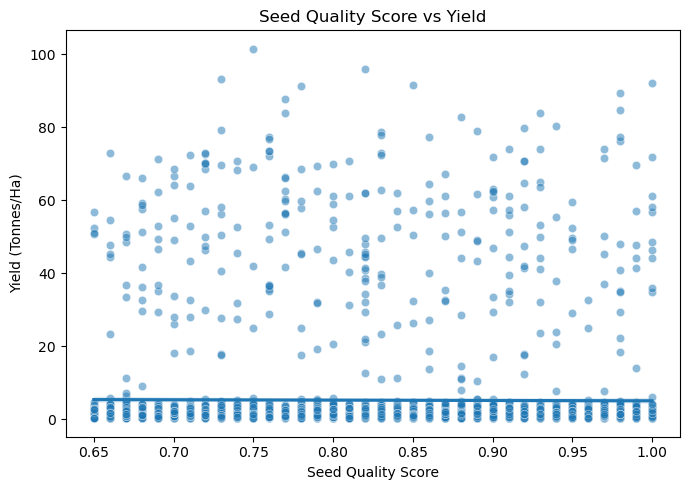

Correlation between seed quality and yield: -0.007


In [ ]:

# Cell 28 — Seed quality analysis

r = data["Seed_Quality_Score"].corr(data["Yield_Tonnes_Ha"])

plt.figure(figsize=(7, 5))
sns.scatterplot(data=data, x="Seed_Quality_Score", y="Yield_Tonnes_Ha", alpha=0.5)
sns.regplot(data=data, x="Seed_Quality_Score", y="Yield_Tonnes_Ha", scatter=False)
plt.title("Seed Quality Score vs Yield")
plt.xlabel("Seed Quality Score")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

print(f"Correlation between seed quality and yield: {r:.3f}")


## 12. Key Question 7 — How do economic outcomes vary across seasons?

In [ ]:

# Cell 29 — Economic performance

economic = data.groupby("Season").agg(
    Avg_Revenue=("Revenue_INR", "mean"),
    Avg_Cost=("Total_Cost_INR", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Profit_Margin=("Profit_Margin_pct", "mean"),
    Avg_Revenue_per_Hectare=("Revenue_per_Hectare_INR", "mean"),
    Avg_Profit_per_Hectare=("Profit_per_Hectare_INR", "mean")
).sort_values("Avg_Profit", ascending=False)

display(economic.round(2))


,Avg_Revenue,Avg_Cost,Avg_Profit,Avg_Profit_Margin,Avg_Revenue_per_Hectare,Avg_Profit_per_Hectare
Season,,,,,,
Kharif,"710,719.06","531,804.41","178,914.65",-38.64,"88,782.79","21,881.81"
Rabi,"601,526.05","513,836.58","87,689.47",-44.27,"76,656.92","10,361.68"
Zaid,"519,171.90","543,976.73","-24,804.82",-69.35,"64,301.42","-2,636.52"


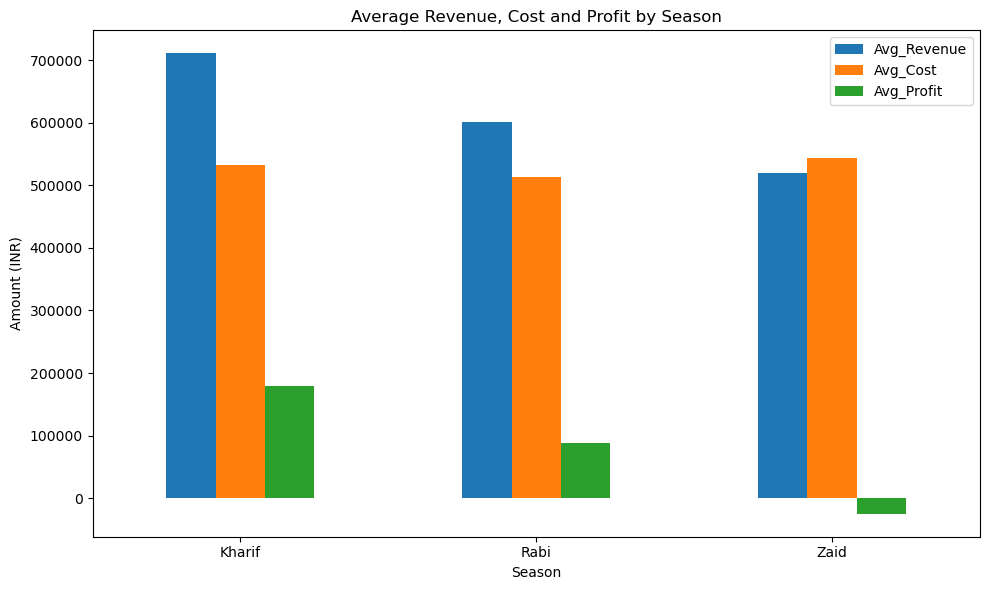

In [ ]:

# Cell 30 — Revenue, cost and profit

economic[["Avg_Revenue", "Avg_Cost", "Avg_Profit"]].plot(
    kind="bar", figsize=(10, 6)
)

plt.title("Average Revenue, Cost and Profit by Season")
plt.xlabel("Season")
plt.ylabel("Amount (INR)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 13. Key Question 8 — Which crops are most profitable?

,Farms,Avg_Revenue,Avg_Cost,Avg_Profit,Avg_Profit_Margin,Avg_Yield
Crop,,,,,,
Sugarcane,305,"1,371,980.11","554,792.13","817,187.99",27.35,46.64
Chilli,412,"1,276,777.23","525,898.89","750,878.34",33.78,1.54
Cotton,508,"639,423.08","514,876.17","124,546.92",-8.23,1.23
Groundnut,424,"542,935.50","498,077.38","44,858.12",-28.66,1.32
Pulses,496,"528,465.87","532,703.92","-4,238.05",-36.48,0.92
Maize,551,"457,067.99","541,046.32","-83,978.33",-81.54,2.71
Rice,690,"423,615.26","525,828.76","-102,213.50",-99.37,2.43
Wheat,614,"400,104.89","523,503.22","-123,398.34",-91.70,2.11


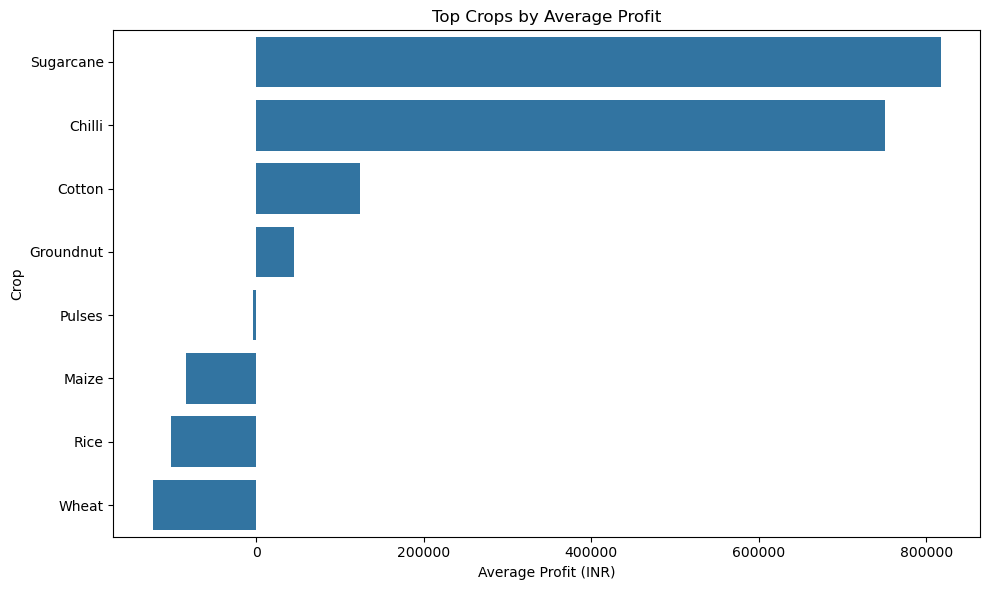

In [ ]:

# Cell 31 — Crop profitability

crop_profit = data.groupby("Crop").agg(
    Farms=("Farm_ID", "count"),
    Avg_Revenue=("Revenue_INR", "mean"),
    Avg_Cost=("Total_Cost_INR", "mean"),
    Avg_Profit=("Profit_INR", "mean"),
    Avg_Profit_Margin=("Profit_Margin_pct", "mean"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean")
).sort_values("Avg_Profit", ascending=False)

display(crop_profit.round(2))

top = crop_profit.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(y=top.index, x=top["Avg_Profit"])
plt.title("Top Crops by Average Profit")
plt.xlabel("Average Profit (INR)")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()


## 14. Key Question 9 — Which seasons use water most efficiently?

,Avg_Water_Used,Avg_Water_Efficiency,Avg_Yield
Season,,,
Kharif,"6,102.20",5.89,5.63
Rabi,"5,846.99",5.19,5.04
Zaid,"6,419.89",4.41,4.64


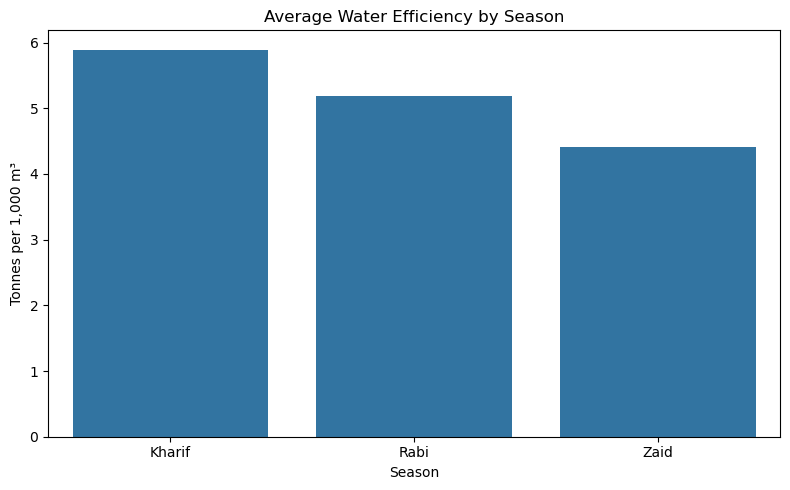

In [ ]:

# Cell 32 — Water efficiency

water_season = data.groupby("Season").agg(
    Avg_Water_Used=("Water_Used_m3", "mean"),
    Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean")
).sort_values("Avg_Water_Efficiency", ascending=False)

display(water_season.round(3))

plt.figure(figsize=(8, 5))
sns.barplot(
    data=water_season.reset_index(),
    x="Season",
    y="Avg_Water_Efficiency"
)
plt.title("Average Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Tonnes per 1,000 m³")
plt.tight_layout()
plt.show()


## 15. Key Question 10 — How does disease/pest risk vary?

,Average_Risk_pct
Season,
Kharif,54.47
Rabi,40.48
Zaid,38.22


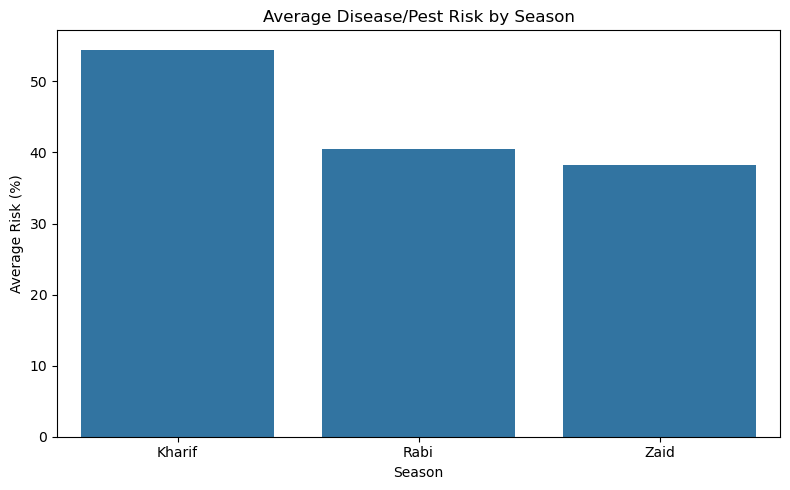

,Average_Risk_pct
Crop,
Wheat,47.85
Pulses,46.57
Rice,46.50
Groundnut,46.29
Chilli,46.06
Cotton,45.97
Maize,45.54
Sugarcane,45.40


In [ ]:

# Cell 33 — Disease/pest risk

risk_season = (
    data.groupby("Season")["Disease_Pest_Risk_pct"]
    .mean()
    .sort_values(ascending=False)
)

display(risk_season.to_frame("Average_Risk_pct").round(2))

plt.figure(figsize=(8, 5))
sns.barplot(x=risk_season.index, y=risk_season.values)
plt.title("Average Disease/Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Average Risk (%)")
plt.tight_layout()
plt.show()

risk_crop = (
    data.groupby("Crop")["Disease_Pest_Risk_pct"]
    .mean()
    .sort_values(ascending=False)
)

display(risk_crop.to_frame("Average_Risk_pct").round(2))


## 16. Overall Correlation Analysis

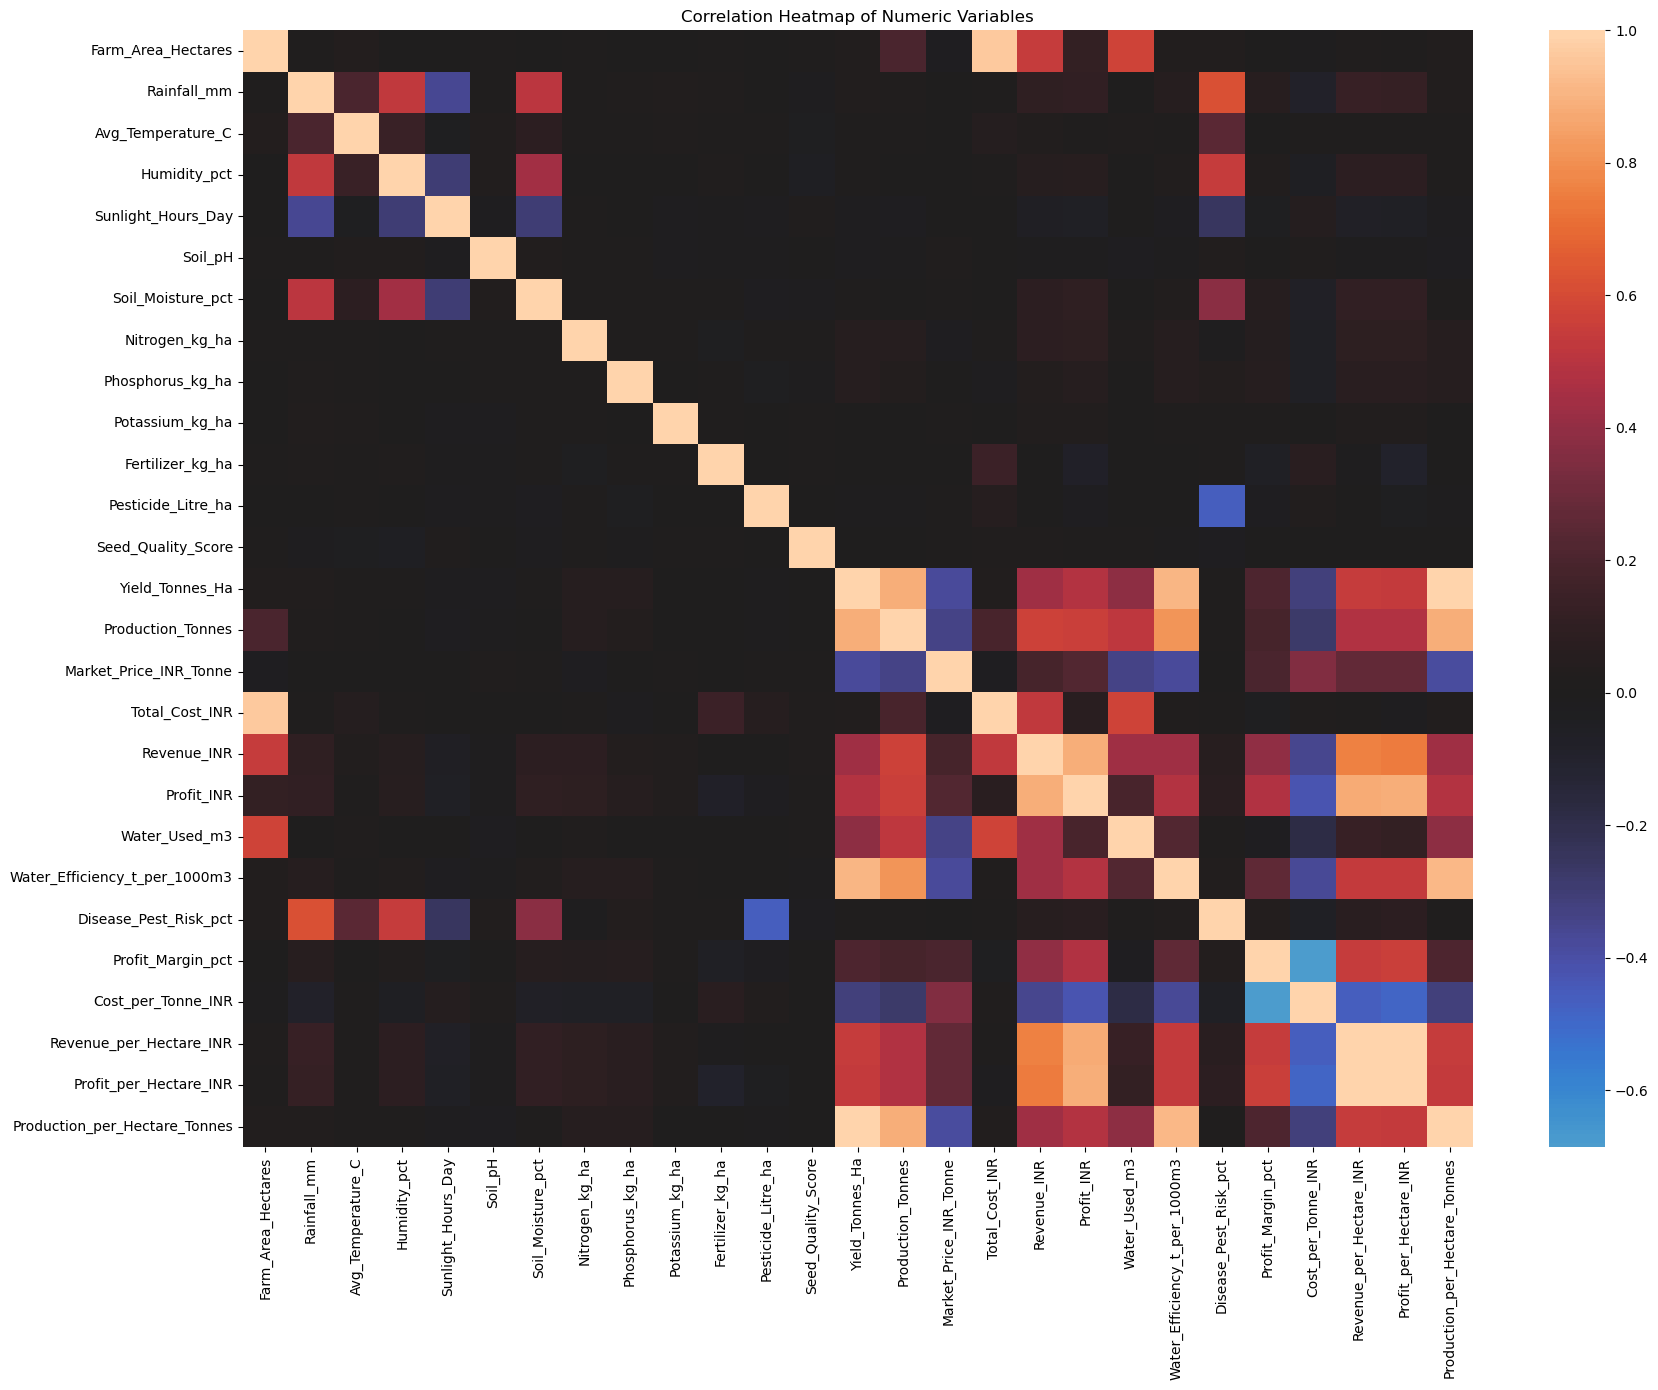

In [ ]:

# Cell 34 — Full numeric correlation heatmap

numeric_cols = data.select_dtypes(include=np.number).columns
corr = data[numeric_cols].corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr, center=0)
plt.title("Correlation Heatmap of Numeric Variables")
plt.tight_layout()
plt.show()


In [ ]:

# Cell 35 — Strongest variables associated with yield and profit

yield_corr = (
    data[numeric_cols]
    .corr()["Yield_Tonnes_Ha"]
    .drop("Yield_Tonnes_Ha")
    .sort_values(key=abs, ascending=False)
)

profit_corr = (
    data[numeric_cols]
    .corr()["Profit_INR"]
    .drop("Profit_INR")
    .sort_values(key=abs, ascending=False)
)

print("Top variables associated with Yield:")
display(yield_corr.head(10).to_frame("Correlation"))

print("Top variables associated with Profit:")
display(profit_corr.head(10).to_frame("Correlation"))


Top variables associated with Yield:


,Correlation
Production_per_Hectare_Tonnes,1.00
Water_Efficiency_t_per_1000m3,0.91
Production_Tonnes,0.88
Revenue_per_Hectare_INR,0.54
Profit_per_Hectare_INR,0.54
Profit_INR,0.49
Revenue_INR,0.43
Water_Used_m3,0.39
Market_Price_INR_Tonne,-0.38
Cost_per_Tonne_INR,-0.31


Top variables associated with Profit:


,Correlation
Revenue_INR,0.89
Profit_per_Hectare_INR,0.89
Revenue_per_Hectare_INR,0.88
Production_Tonnes,0.55
Production_per_Hectare_Tonnes,0.49
Water_Efficiency_t_per_1000m3,0.49
Yield_Tonnes_Ha,0.49
Profit_Margin_pct,0.48
Cost_per_Tonne_INR,-0.42
Market_Price_INR_Tonne,0.23


## 17. Outlier Analysis

In [ ]:

# Cell 36 — IQR outlier detection

outlier_cols = [
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Revenue_INR",
    "Total_Cost_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Disease_Pest_Risk_pct"
]

results = []

for col in outlier_cols:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((data[col] < lower) | (data[col] > upper)).sum()
    results.append([col, q1, q3, lower, upper, count])

outlier_table = pd.DataFrame(
    results,
    columns=["Variable", "Q1", "Q3", "Lower_Bound", "Upper_Bound", "Outlier_Count"]
)

display(outlier_table.round(2))


,Variable,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Count
0,Yield_Tonnes_Ha,1.05,2.83,-1.62,5.50,302
1,Production_Tonnes,5.02,24.36,-23.98,53.36,333
2,Revenue_INR,"207,517.25","836,874.75","-736,519.00","1,780,911.00",240
3,Total_Cost_INR,"274,577.50","761,996.50","-456,551.00","1,493,125.00",0
4,Profit_INR,"-148,731.75","216,187.75","-696,111.00","763,567.00",404
5,Water_Used_m3,"2,268.75","7,829.75","-6,072.75","16,171.25",276
6,Disease_Pest_Risk_pct,37.30,54.90,10.90,81.30,10


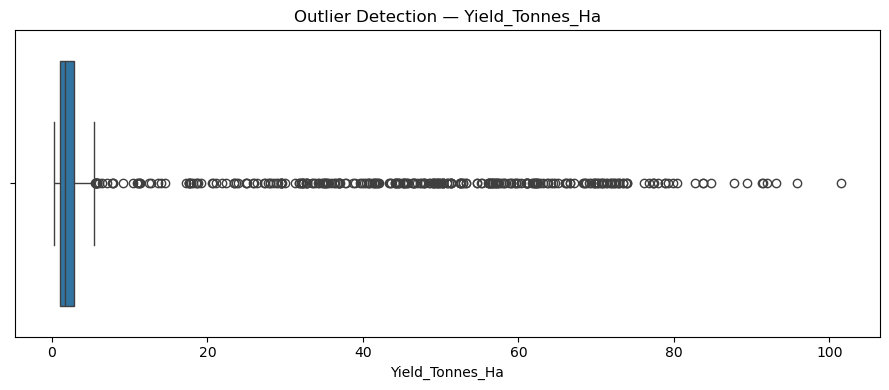

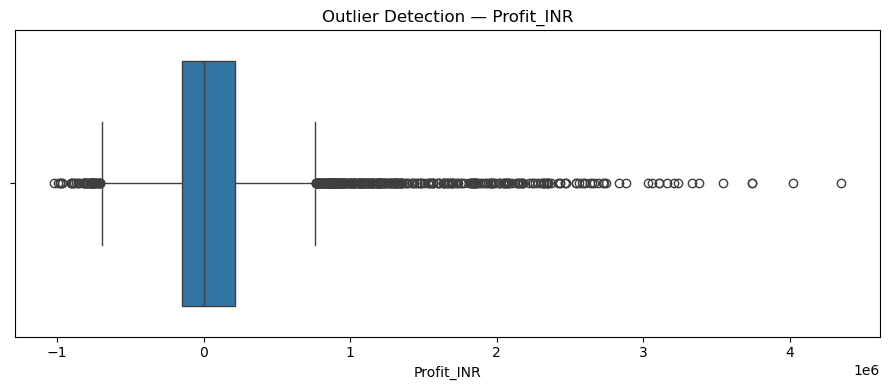

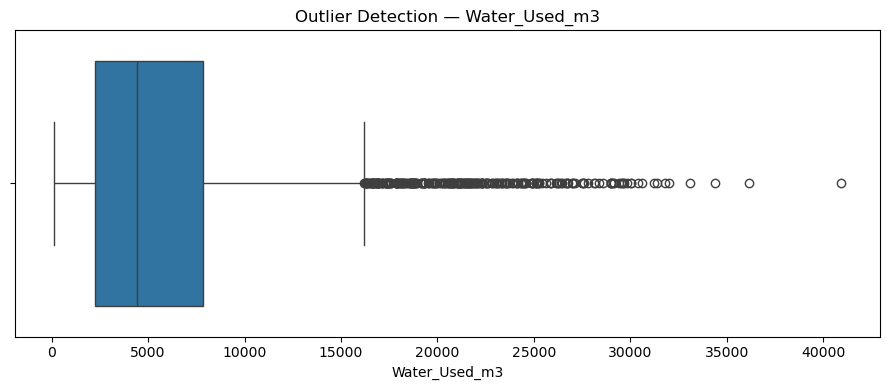

In [ ]:

# Cell 37 — Visualize important outliers

for col in ["Yield_Tonnes_Ha", "Profit_INR", "Water_Used_m3"]:
    plt.figure(figsize=(9, 4))
    sns.boxplot(x=data[col])
    plt.title(f"Outlier Detection — {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


## 18. Statistical Analysis — Do seasons differ significantly in yield?

In [ ]:

# Cell 38 — ANOVA and Kruskal-Wallis tests

groups = [
    group["Yield_Tonnes_Ha"].dropna().values
    for _, group in data.groupby("Season")
]

anova_stat, anova_p = stats.f_oneway(*groups)
kw_stat, kw_p = stats.kruskal(*groups)

print(f"ANOVA statistic: {anova_stat:.4f}")
print(f"ANOVA p-value:   {anova_p:.6f}")

print(f"\nKruskal-Wallis statistic: {kw_stat:.4f}")
print(f"Kruskal-Wallis p-value:   {kw_p:.6f}")

alpha = 0.05

if anova_p < alpha:
    print("\nANOVA: Significant evidence of a difference in mean yield among seasons.")
else:
    print("\nANOVA: Insufficient evidence of a difference in mean yield among seasons.")

if kw_p < alpha:
    print("Kruskal-Wallis: Yield distributions differ significantly among seasons.")
else:
    print("Kruskal-Wallis: Insufficient evidence of different yield distributions among seasons.")


ANOVA statistic: 1.5439
ANOVA p-value:   0.213678

Kruskal-Wallis statistic: 68.7131
Kruskal-Wallis p-value:   0.000000

ANOVA: Insufficient evidence of a difference in mean yield among seasons.
Kruskal-Wallis: Yield distributions differ significantly among seasons.


## 19. Pairwise Seasonal Comparison

In [ ]:

# Cell 39 — Pairwise Mann-Whitney U tests with Bonferroni correction

seasons = data["Season"].dropna().unique().tolist()
pairwise_results = []

for i in range(len(seasons)):
    for j in range(i + 1, len(seasons)):
        s1, s2 = seasons[i], seasons[j]

        x = data.loc[data["Season"] == s1, "Yield_Tonnes_Ha"].dropna()
        y = data.loc[data["Season"] == s2, "Yield_Tonnes_Ha"].dropna()

        u, p = stats.mannwhitneyu(x, y, alternative="two-sided")
        pairwise_results.append([s1, s2, u, p])

pairwise = pd.DataFrame(
    pairwise_results,
    columns=["Season_1", "Season_2", "U_Statistic", "Raw_p_value"]
)

m = len(pairwise)
pairwise["Bonferroni_p_value"] = np.minimum(pairwise["Raw_p_value"] * m, 1.0)
pairwise["Significant_at_0.05"] = pairwise["Bonferroni_p_value"] < 0.05

display(pairwise.sort_values("Bonferroni_p_value").round(6))


,Season_1,Season_2,U_Statistic,Raw_p_value,Bonferroni_p_value,Significant_at_0.05
1,Kharif,Zaid,"641,420.50",0.00,0.00,True
0,Kharif,Rabi,"1,594,739.00",0.00,0.00,True
2,Rabi,Zaid,"539,638.50",0.00,0.00,True


## 20. Automatically Generated Key Findings

In [ ]:

# Cell 40 — Generate findings from actual calculated results

best_yield = season_summary["Avg_Yield_Tonnes_Ha"].idxmax()
best_profit = season_summary["Avg_Profit_INR"].idxmax()
best_water = season_summary["Avg_Water_Efficiency"].idxmax()
lowest_risk = season_summary["Avg_Disease_Pest_Risk_pct"].idxmin()

best_crop = crop_profit["Avg_Profit"].idxmax()
best_state = state_summary["Avg_Profit"].idxmax()

strongest_yield_factor = yield_corr.index[0]
strongest_yield_corr = yield_corr.iloc[0]

print("KEY FINDINGS")
print("-" * 70)
print(f"1. Highest average yield season: {best_yield}")
print(f"   Average yield: {season_summary.loc[best_yield, 'Avg_Yield_Tonnes_Ha']:.2f} tonnes/ha")

print(f"\n2. Highest average profit season: {best_profit}")
print(f"   Average profit: ₹{season_summary.loc[best_profit, 'Avg_Profit_INR']:,.2f}")

print(f"\n3. Highest water-efficiency season: {best_water}")
print(f"   Efficiency: {season_summary.loc[best_water, 'Avg_Water_Efficiency']:.3f} tonnes/1,000 m³")

print(f"\n4. Lowest disease/pest risk season: {lowest_risk}")
print(f"   Risk: {season_summary.loc[lowest_risk, 'Avg_Disease_Pest_Risk_pct']:.2f}%")

print(f"\n5. Most profitable crop on average: {best_crop}")
print(f"   Average profit: ₹{crop_profit.loc[best_crop, 'Avg_Profit']:,.2f}")

print(f"\n6. Highest average-profit state: {best_state}")
print(f"   Average profit: ₹{state_summary.loc[best_state, 'Avg_Profit']:,.2f}")

print(f"\n7. Strongest absolute numeric correlation with yield: {strongest_yield_factor}")
print(f"   Correlation: {strongest_yield_corr:.3f}")


KEY FINDINGS
----------------------------------------------------------------------
1. Highest average yield season: Kharif
   Average yield: 5.63 tonnes/ha

2. Highest average profit season: Kharif
   Average profit: ₹178,914.65

3. Highest water-efficiency season: Kharif
   Efficiency: 5.892 tonnes/1,000 m³

4. Lowest disease/pest risk season: Zaid
   Risk: 38.22%

5. Most profitable crop on average: Sugarcane
   Average profit: ₹817,187.99

6. Highest average-profit state: Punjab
   Average profit: ₹136,025.64

7. Strongest absolute numeric correlation with yield: Production_per_Hectare_Tonnes
   Correlation: 0.997


## 21. Evidence-Based Recommendations
1. Prioritize seasonal planning around Kharif, which has the highest observed average yield.
2. Study the practices associated with Kharif, which has the highest observed average profit.
3. Evaluate water-management practices associated with Kharif, the highest water-efficiency season.
4. Strengthen disease/pest monitoring in seasons with comparatively higher observed risk.
5. Study Sugarcane, the crop with the highest average profit, before considering wider adoption.
6. Investigate Production_per_Hectare_Tonnes further because it has the strongest absolute numeric correlation with yield.


## 22. Interpretation Note

Correlation indicates association, not causation. A strong correlation does not prove that changing one factor alone will change yield or profit.

Seasonal differences may also be affected by crop mix, geography, farming practices, soil conditions, market conditions and other variables. Therefore, the recommendations are evidence-based areas for further investigation rather than guaranteed causal effects.


## 23. Final Conclusion
Conclusion
The analysis covered 4,000 agricultural records across 3 seasons, 8 crops and 8 states.

The overall average yield was 5.24 tonnes/ha and the overall average profit was ₹111,556.46. Kharif recorded the highest average yield, while Kharif recorded the highest average profit.

Kharif had the highest average water efficiency, while Zaid had the lowest average disease/pest risk. The strongest absolute numeric correlation with yield was Production_per_Hectare_Tonnes (correlation = 0.997).

Overall, the project demonstrates how seasonal agricultural data can be used to compare performance, understand resource and environmental patterns, examine economic outcomes and support evidence-based seasonal agricultural planning.


# End of Project

### Suggested PPT structure

1. Title
2. Introduction
3. Problem Statement
4. Objectives
5. Dataset Description
6. Data Cleaning
7. Analytical Questions
8. Seasonal Performance
9. Crop Analysis
10. Regional Analysis
11. Environmental Analysis
12. Resource and Irrigation Analysis
13. Economic Analysis
14. Water Efficiency
15. Disease/Pest Risk
16. Correlation Analysis
17. Statistical Testing
18. Key Findings
19. Recommendations
20. Conclusion

Use screenshots of the important tables and charts generated by this notebook in your final PPT.
